# Chapter 4: Exploratory Data Analysis for Project Report

## Setup and Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from statsmodels.tsa.seasonal import STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

sns.set_theme(style="whitegrid")
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["savefig.dpi"] = 150
mpl.rcParams["font.size"] = 11

FIG = "figs"
os.makedirs(FIG, exist_ok=True)

LOG = open("numbers.txt", "w")

def log(*a):
    s = " ".join(str(x) for x in a)
    print(s)
    LOG.write(s + "\n")

## 4.1 Data, Environment and Preparation

In [2]:


from pathlib import Path

repo_root = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "data" / "NSW" / "nsw_features_added.csv").exists()
)
file_path = repo_root / "data" / "NSW" / "nsw_features_added.csv"

df = pd.read_csv(file_path)
df["DATETIME"] = pd.to_datetime(df["DATETIME"], errors="coerce")
df = df.sort_values("DATETIME").reset_index(drop=True)
log("rows", df.shape[0], "cols", df.shape[1])
log("invalid timestamps", df["DATETIME"].isna().sum())
log("first", df["DATETIME"].min(), "last", df["DATETIME"].max())
log("missing values total", df.isna().sum().sum())
log("duplicate timestamps", df["DATETIME"].duplicated().sum())
log("regions", df["REGIONID"].unique())

diffs = df["DATETIME"].diff().value_counts()
log("interval counts:\n", diffs)

expected = pd.date_range(
    df["DATETIME"].min(),
    df["DATETIME"].max(),
    freq="30min"
)

missing_stamps = expected.difference(df["DATETIME"])
log("missing 30 min stamps", len(missing_stamps))

df = df.drop(columns=["radiation"], errors="ignore")
log("columns after dropping radiation", df.shape[1])

rows 196513 cols 15
invalid timestamps 0
first 2010-01-01 00:00:00 last 2021-03-18 00:00:00
missing values total 0
duplicate timestamps 0
regions ['NSW1']
interval counts:
 DATETIME
0 days 00:30:00    196512
Name: count, dtype: int64
missing 30 min stamps 0
columns after dropping radiation 14


## 4.2 Distribution of Demand and Outliers

count    196513.000000
mean       8113.145859
std        1299.532774
min        5074.630000
25%        7150.070000
50%        8053.230000
75%        8958.550000
max       14579.860000
Name: TOTALDEMAND, dtype: float64
skew 0.441308695260564 kurtosis 0.10008746297367876


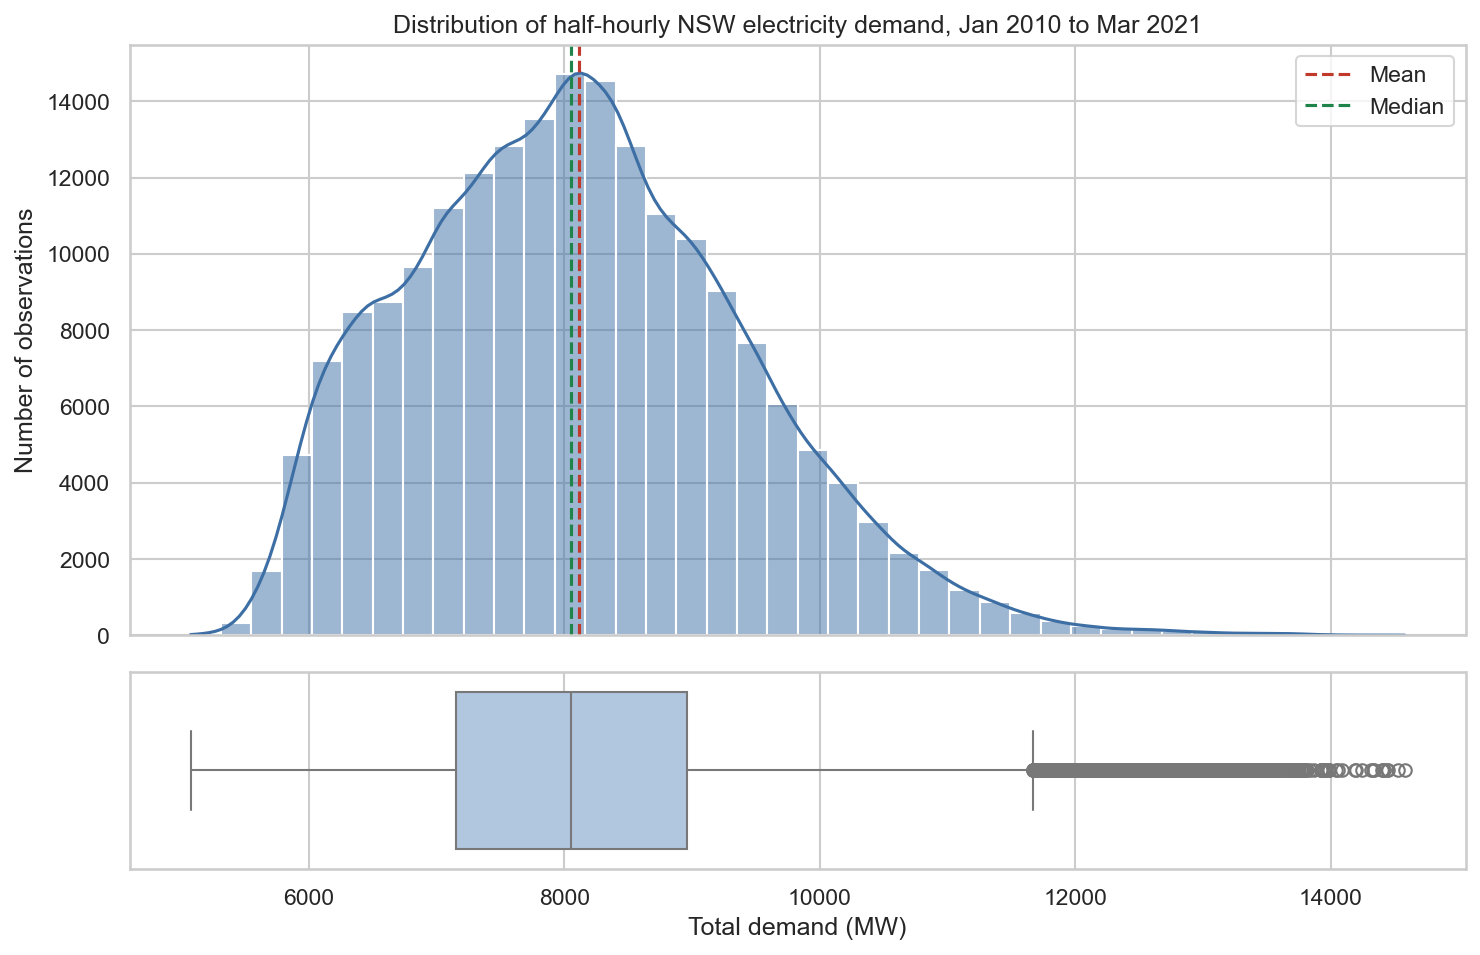

In [3]:

summ = df["TOTALDEMAND"].describe()
log(summ)

log(
    "skew",
    df["TOTALDEMAND"].skew(),
    "kurtosis",
    df["TOTALDEMAND"].kurtosis()
)

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 6.5),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True
)

sns.histplot(
    data=df,
    x="TOTALDEMAND",
    bins=40,
    kde=True,
    ax=axes[0],
    color="#3d6fa5"
)

axes[0].axvline(
    df["TOTALDEMAND"].mean(),
    color="#c0392b",
    linestyle="--",
    label="Mean"
)

axes[0].axvline(
    df["TOTALDEMAND"].median(),
    color="#1e8449",
    linestyle="--",
    label="Median"
)

axes[0].set_title(
    "Distribution of half-hourly NSW electricity demand, Jan 2010 to Mar 2021"
)

axes[0].set_ylabel("Number of observations")
axes[0].legend()

sns.boxplot(
    data=df,
    x="TOTALDEMAND",
    ax=axes[1],
    color="#a9c6e8"
)

axes[1].set_xlabel("Total demand (MW)")

plt.tight_layout()
plt.savefig(f"{FIG}/fig_distribution.png")
plt.show()

*Figure 4.1. Distribution of half-hourly NSW electricity demand, with a boxplot below.*

In [4]:
# Outlier rules

q1, q3 = df["TOTALDEMAND"].quantile([0.25, 0.75])
iqr = q3 - q1

lb = q1 - 1.5 * iqr
ub = q3 + 1.5 * iqr

df["FLAG_POOLED"] = (
    (df["TOTALDEMAND"] < lb) |
    (df["TOTALDEMAND"] > ub)
)

slot = df["DATETIME"].dt.hour + df["DATETIME"].dt.minute / 60

by_slot = df.groupby(slot)["TOTALDEMAND"]

df["Z_BY_SLOT"] = (
    (df["TOTALDEMAND"] - by_slot.transform("mean")) /
    by_slot.transform("std")
)

df["FLAG_SLOT"] = df["Z_BY_SLOT"].abs() > 3

log("pooled bounds", round(lb, 2), round(ub, 2))

log(
    "pooled flagged",
    df["FLAG_POOLED"].sum(),
    "pct",
    round(df["FLAG_POOLED"].mean() * 100, 2)
)

log(
    "slot flagged",
    df["FLAG_SLOT"].sum(),
    "pct",
    round(df["FLAG_SLOT"].mean() * 100, 2)
)

log(
    "flagged by both",
    (df["FLAG_POOLED"] & df["FLAG_SLOT"]).sum()
)

log(
    "flagged only by slot",
    (~df["FLAG_POOLED"] & df["FLAG_SLOT"]).sum()
)

log(
    "slot low flags",
    (df["Z_BY_SLOT"] < -3).sum()
)

run_id = (
    df["FLAG_POOLED"] != df["FLAG_POOLED"].shift()
).cumsum()

run_lengths = (
    df[df["FLAG_POOLED"]]
    .groupby(run_id[df["FLAG_POOLED"]])
    .size()
)

log(
    "num runs", len(run_lengths),
    "isolated", (run_lengths == 1).sum(),
    "runs>=3hr", (run_lengths >= 6).sum(),
    "longest", run_lengths.max(),
    "share in long runs pct",
    round(
        run_lengths[run_lengths >= 6].sum()
        / run_lengths.sum() * 100,
        1
    )
)

pooled bounds 4437.35 11671.27
pooled flagged 1415 pct 0.72
slot flagged 892 pct 0.45
flagged by both 704
flagged only by slot 188
slot low flags 3
num runs 213 isolated 24 runs>=3hr 84 longest 26 share in long runs pct 74.2


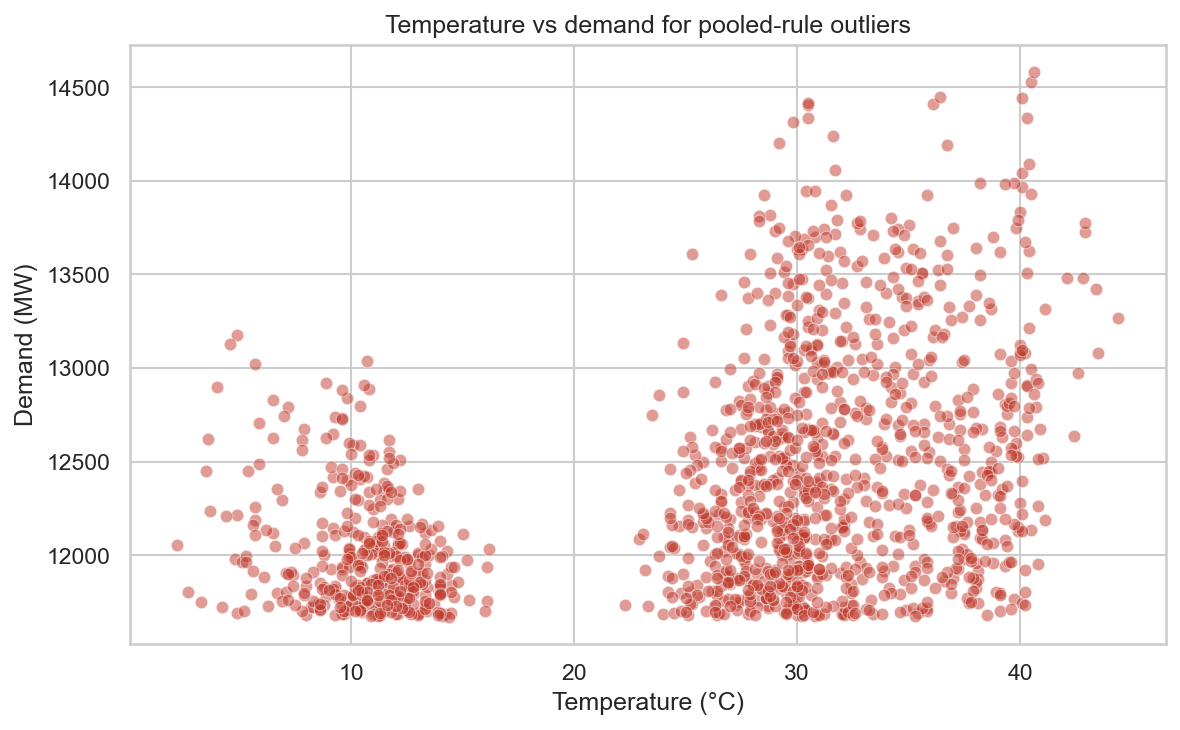

In [5]:
# Figure 4.2: Temperature against demand for pooled-rule outliers

flagged = df[df["FLAG_POOLED"]]

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=flagged,
    x="TEMPERATURE",
    y="TOTALDEMAND",
    color="#c0392b",
    alpha=0.5
)

plt.title("Temperature vs demand for pooled-rule outliers")
plt.xlabel("Temperature (°C)")
plt.ylabel("Demand (MW)")

plt.tight_layout()
plt.savefig(f"{FIG}/fig_outlier_temp.png")
plt.show()

*Figure 4.2. Temperature against demand for observations flagged by the pooled rule.*

## 4.3 Temporal Structure of Demand

### 4.3.1 Daily and Weekly Pattern

daily minimum 6322.69 MW at 4.0
daily maximum 9375.04 MW at 18.5
peak-to-trough increase pct 48.28


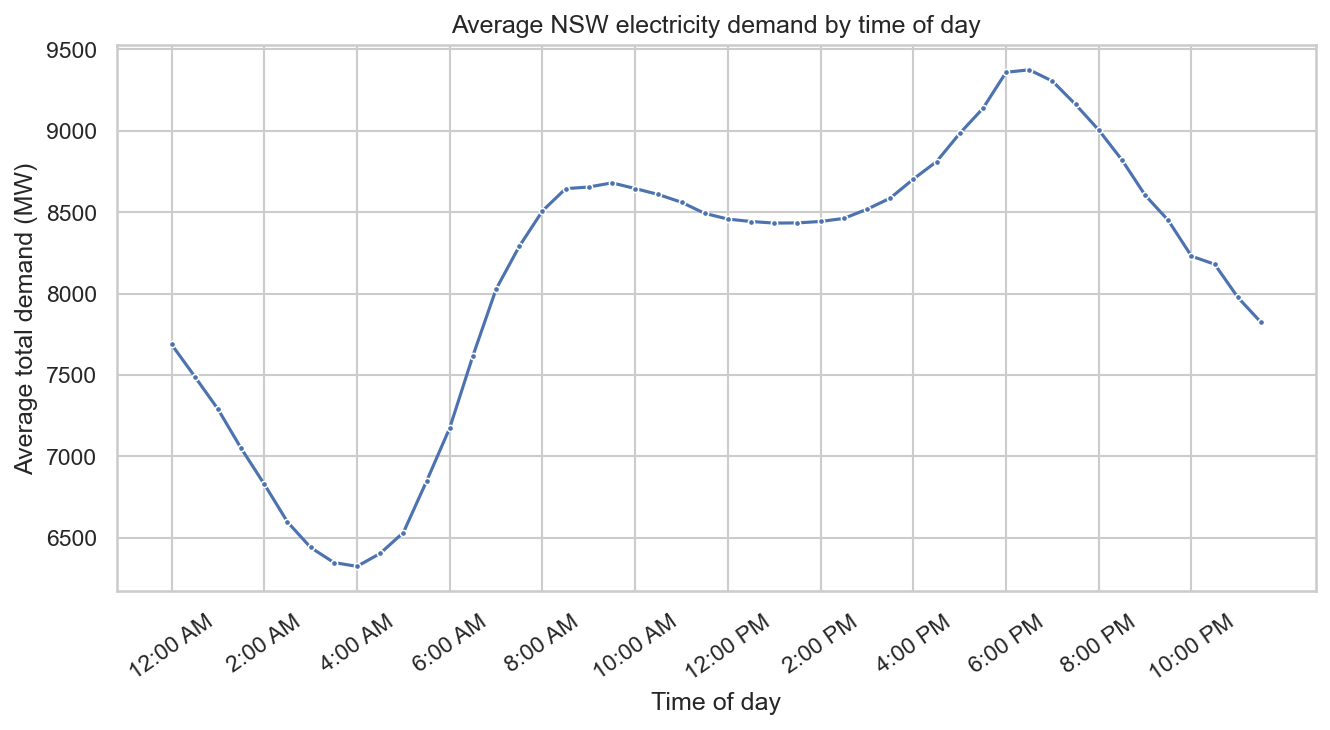

In [6]:
# Figure 4.3: Average NSW electricity demand by time of day

df["HOUR"] = (
    df["DATETIME"].dt.hour
    + df["DATETIME"].dt.minute / 60
)

hourly = (
    df.groupby("HOUR", observed=True)["TOTALDEMAND"]
    .mean()
    .reset_index()
)

low = hourly.loc[hourly["TOTALDEMAND"].idxmin()]
high = hourly.loc[hourly["TOTALDEMAND"].idxmax()]

log(
    "daily minimum",
    round(low["TOTALDEMAND"], 2),
    "MW at",
    low["HOUR"]
)

log(
    "daily maximum",
    round(high["TOTALDEMAND"], 2),
    "MW at",
    high["HOUR"]
)

log(
    "peak-to-trough increase pct",
    round(
        (high["TOTALDEMAND"] / low["TOTALDEMAND"] - 1) * 100,
        2
    )
)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=hourly,
    x="HOUR",
    y="TOTALDEMAND",
    marker="o",
    markersize=3
)

plt.title("Average NSW electricity demand by time of day")
plt.xlabel("Time of day")
plt.ylabel("Average total demand (MW)")

plt.xticks(
    range(0, 24, 2),
    [
        "12:00 AM", "2:00 AM", "4:00 AM", "6:00 AM",
        "8:00 AM", "10:00 AM", "12:00 PM", "2:00 PM",
        "4:00 PM", "6:00 PM", "8:00 PM", "10:00 PM"
    ],
    rotation=35
)

plt.tight_layout()
plt.savefig(f"{FIG}/fig_daily_profile.png")
plt.show()

*Figure 4.3. Average NSW electricity demand by time of day.*

weekday profile:
      WEEKDAY  TOTALDEMAND
0     Monday  8233.071258
1    Tuesday  8358.963726
2  Wednesday  8326.009179
3   Thursday  8351.029746
4     Friday  8307.184395
5   Saturday  7717.352718
6     Sunday  7498.808161
weekday mean 8315.24 weekend mean 7608.08 diff 707.16 pct 9.29


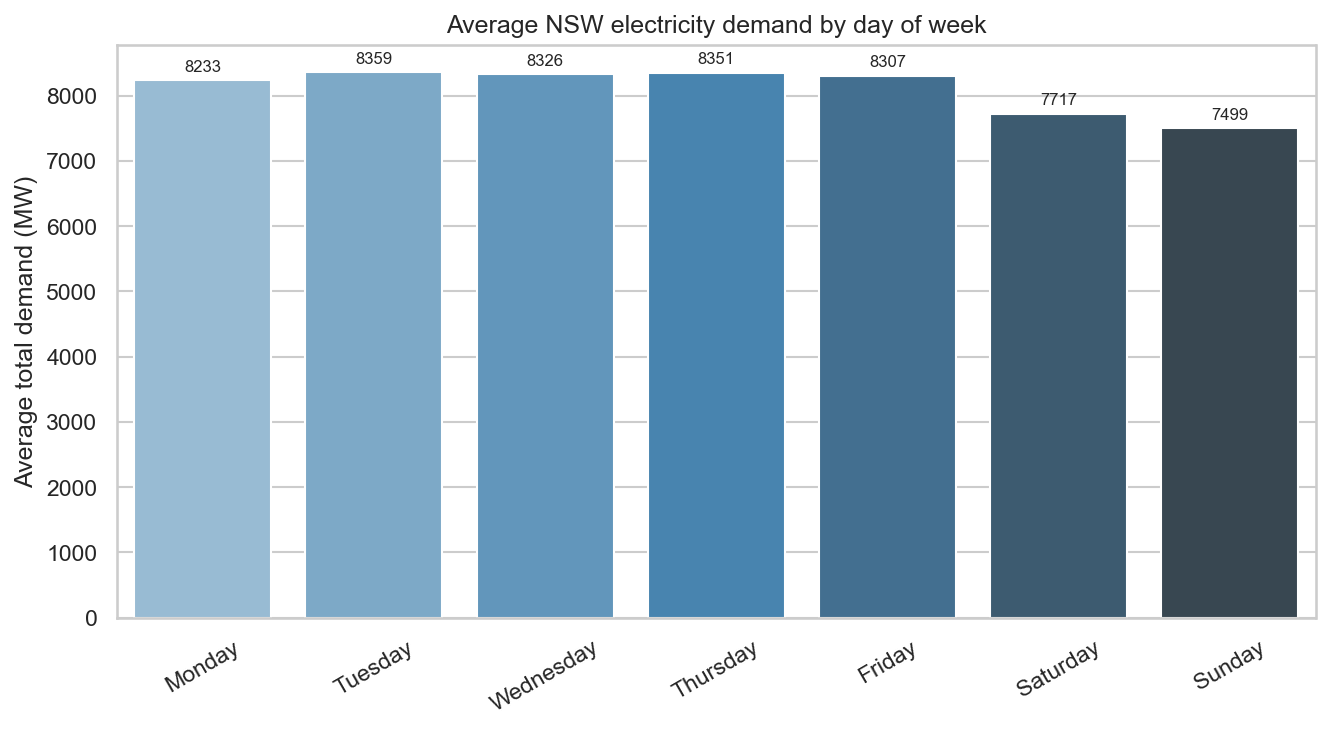

In [7]:
# Figure 4.4: Average NSW electricity demand by day of week

df["WEEKDAY"] = df["DATETIME"].dt.day_name()
df["DAY_NUMBER"] = df["DATETIME"].dt.dayofweek
df["IS_WEEKEND"] = df["DAY_NUMBER"] >= 5

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_profile = (
    df.groupby("WEEKDAY", observed=True)["TOTALDEMAND"]
    .mean()
    .reindex(day_order)
    .reset_index()
)

wmean = df.loc[~df["IS_WEEKEND"], "TOTALDEMAND"].mean()
wend = df.loc[df["IS_WEEKEND"], "TOTALDEMAND"].mean()

log("weekday profile:\n", weekday_profile)

log(
    "weekday mean", round(wmean, 2),
    "weekend mean", round(wend, 2),
    "diff", round(wmean - wend, 2),
    "pct", round((wmean / wend - 1) * 100, 2)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=weekday_profile,
    x="WEEKDAY",
    y="TOTALDEMAND",
    hue="WEEKDAY",
    palette="Blues_d",
    legend=False
)

for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", padding=3, fontsize=8)

plt.title("Average NSW electricity demand by day of week")
plt.xlabel("")
plt.ylabel("Average total demand (MW)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(f"{FIG}/fig_weekday.png")
plt.show()

<p style="text-align: center;"><em>Figure 4.4. Average NSW electricity demand by day of week.</em></p>

### 4.3.2 Seasonal pattern and its interaction with day type

In [8]:
season_map = {
    12: "Summer", 1: "Summer", 2: "Summer",
    3: "Autumn", 4: "Autumn", 5: "Autumn",
    6: "Winter", 7: "Winter", 8: "Winter",
    9: "Spring", 10: "Spring", 11: "Spring"
}

df["MONTH"] = df["DATETIME"].dt.month
df["SEASON"] = df["MONTH"].map(season_map)

season_order = ["Summer", "Autumn", "Winter", "Spring"]

In [9]:
def fmt_time(hour):
    ts = pd.Timestamp("2000-01-01") + pd.to_timedelta(hour, unit="h")
    return ts.strftime("%I:%M %p").lstrip("0")

season profile:
    SEASON  TOTALDEMAND
0  Summer  8155.911980
1  Autumn  7906.197641
2  Winter  8738.861348
3  Spring  7648.350649
seasonal summary:
         Average (MW)  Trough (MW) Trough time  Peak (MW) Peak time  \
Season                                                               
Summer       8155.91      6230.65     3:30 AM    9442.20   5:00 PM   
Autumn       7906.20      6173.81     4:00 AM    9157.12   6:30 PM   
Winter       8738.86      6739.58     4:30 AM   10653.74   6:30 PM   
Spring       7648.35      6100.99     3:30 AM    8688.93   7:00 PM   

        Peak/trough %  
Season                 
Summer          51.54  
Autumn          48.32  
Winter          58.08  
Spring          42.42  


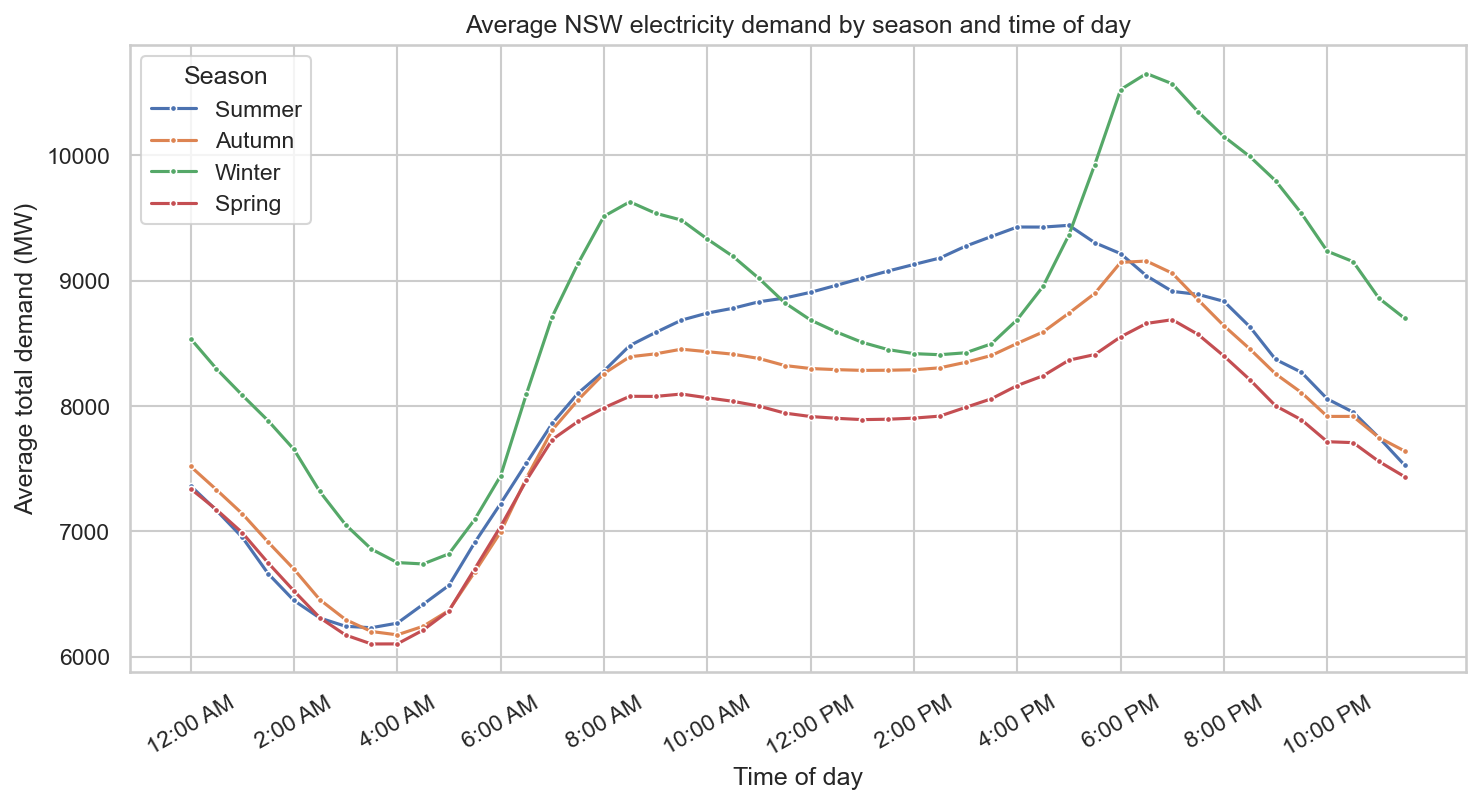

In [10]:
# season profile
season_profile = df.groupby("SEASON", observed=True)["TOTALDEMAND"].mean().reindex(season_order).reset_index()
log("season profile:\n", season_profile)

# seasonal hourly + summary table
seasonal_hourly = df.groupby(["SEASON","HOUR"], observed=True)["TOTALDEMAND"].mean().reset_index()
rows=[]
for s in season_order:
    block = seasonal_hourly[seasonal_hourly["SEASON"]==s]
    lo = block.loc[block["TOTALDEMAND"].idxmin()]
    hi = block.loc[block["TOTALDEMAND"].idxmax()]
    rows.append({"Season": s,
                 "Average (MW)": df.loc[df["SEASON"]==s, "TOTALDEMAND"].mean(),
                 "Trough (MW)": lo["TOTALDEMAND"], "Trough time": fmt_time(lo["HOUR"]),
                 "Peak (MW)": hi["TOTALDEMAND"], "Peak time": fmt_time(hi["HOUR"]),
                 "Peak/trough %": (hi["TOTALDEMAND"]/lo["TOTALDEMAND"]-1)*100})
seasonal_summary = pd.DataFrame(rows).set_index("Season")
log("seasonal summary:\n", seasonal_summary.round(2))

plt.figure(figsize=(10,5.5))
sns.lineplot(data=seasonal_hourly, x="HOUR", y="TOTALDEMAND", hue="SEASON",
             hue_order=season_order, marker="o", markersize=3)
plt.xticks(range(0,24,2), [fmt_time(h) for h in range(0,24,2)], rotation=30)
plt.title("Average NSW electricity demand by season and time of day")
plt.xlabel("Time of day"); plt.ylabel("Average total demand (MW)"); plt.legend(title="Season")
plt.tight_layout(); plt.savefig(f"{FIG}/fig_seasonal_hourly.png"); plt.show()

<p style="font-size:18px; font-style:italic;">
Figure 4.5. Average NSW electricity demand by season and time of day.
</p>

In [11]:
df["DAY_NUMBER"] = df["DATETIME"].dt.dayofweek
df["IS_WEEKEND"] = df["DAY_NUMBER"] >= 5
df["DAY_TYPE"] = np.where(df["IS_WEEKEND"], "Weekend", "Weekday")

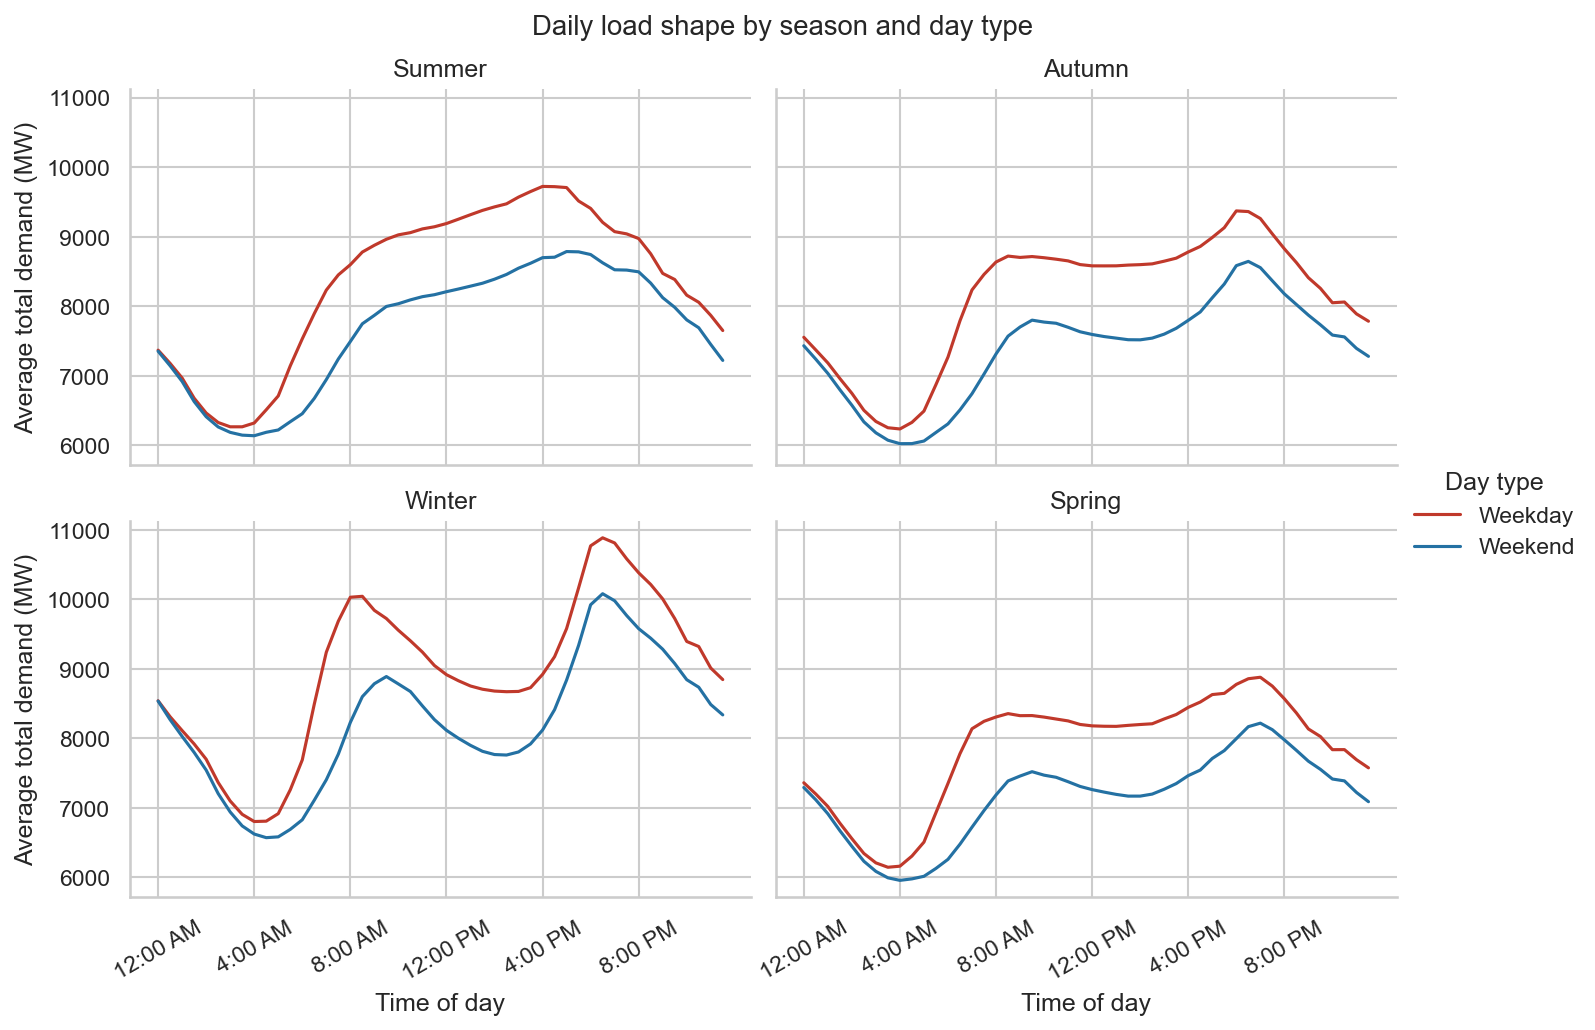

In [12]:
# season x day type
three_way = df.groupby(["SEASON","DAY_TYPE","HOUR"], observed=True)["TOTALDEMAND"].mean().reset_index()

grid = sns.relplot(
    data=three_way,
    x="HOUR",
    y="TOTALDEMAND",
    hue="DAY_TYPE",
    col="SEASON",
    col_order=season_order,
    kind="line",
    col_wrap=2,
    height=3.2,
    aspect=1.5,
    palette={"Weekday":"#C0392B","Weekend":"#2471A3"}
)

grid.set_axis_labels("Time of day", "Average total demand (MW)")
grid.set_titles("{col_name}")
grid._legend.set_title("Day type")

for ax in grid.axes.flat:
    ticks = list(range(0,24,4))
    ax.set_xticks(ticks)
    ax.set_xticklabels([fmt_time(h) for h in ticks], rotation=30)

grid.figure.suptitle("Daily load shape by season and day type", y=1.02)
grid.savefig(f"{FIG}/fig_season_daytype.png", bbox_inches="tight")

plt.show()

<p style="font-size:18px; font-style:italic;">
Figure 4.6. Daily load shape by season and day type.
</p>

### 4.3.3 Monthly and annual movement

In [13]:
df["YEAR"] = df["DATETIME"].dt.year
df["MONTH_NAME"] = df["DATETIME"].dt.month_name()

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly summary:
             average   median       sd
MONTH_NAME                           
January     8419.29  8256.33  1567.04
February    8406.45  8368.51  1444.11
March       7995.62  8001.45  1196.58
April       7586.95  7611.48  1032.52
May         8150.53  8162.13  1141.69
June        8799.72  8817.34  1294.51
July        8894.76  8887.65  1281.07
August      8524.08  8506.84  1193.97
September   7759.18  7794.41   993.87
October     7488.18  7529.93   936.64
November    7703.03  7677.75  1128.33
December    7773.64  7721.20  1255.35


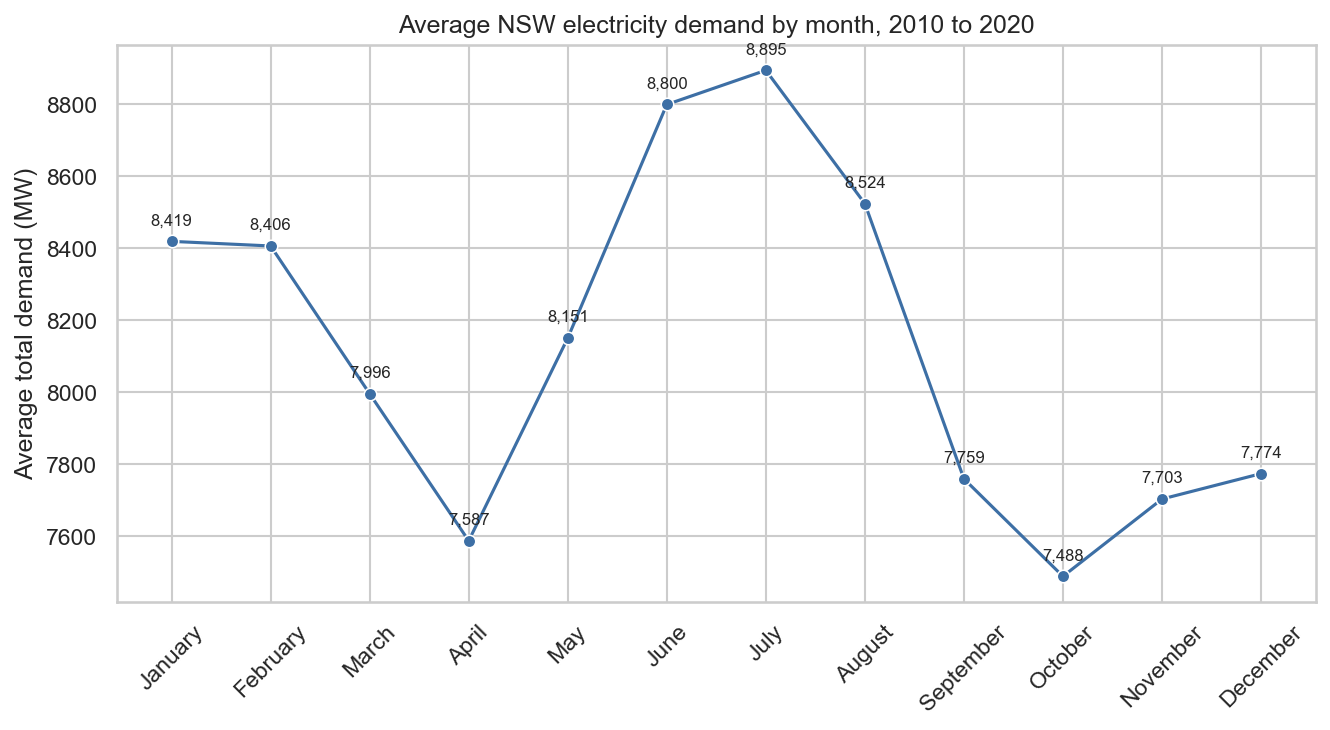

In [14]:
# monthly
complete_years = df[df["YEAR"] < 2021].copy()

monthly_summary = complete_years.groupby("MONTH_NAME")["TOTALDEMAND"].agg(
    average="mean", median="median", sd="std"
).reindex(month_order)

log("monthly summary:\n", monthly_summary.round(2))

plt.figure(figsize=(9,5))
ax = sns.lineplot(
    x=monthly_summary.index,
    y=monthly_summary["average"],
    marker="o",
    color="#3d6fa5"
)

for i,v in enumerate(monthly_summary["average"]):
    ax.annotate(
        f"{v:,.0f}",
        (i,v),
        textcoords="offset points",
        xytext=(0,8),
        ha="center",
        fontsize=8
    )

plt.title("Average NSW electricity demand by month, 2010 to 2020")
plt.xlabel("")
plt.ylabel("Average total demand (MW)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(f"{FIG}/fig_monthly.png")
plt.show()

<p style="font-size:18px; font-style:italic;">
Figure 4.7. Average NSW electricity demand by calendar month, complete years only.
</p>

yearly means:
 YEAR
2010    8807.19
2011    8728.29
2012    8253.29
2013    7981.59
2014    7917.80
2015    7979.76
2016    7977.98
2017    8053.87
2018    7999.90
2019    7964.55
2020    7709.77
Name: TOTALDEMAND, dtype: float64
2010 to 2020 pct change -12.46


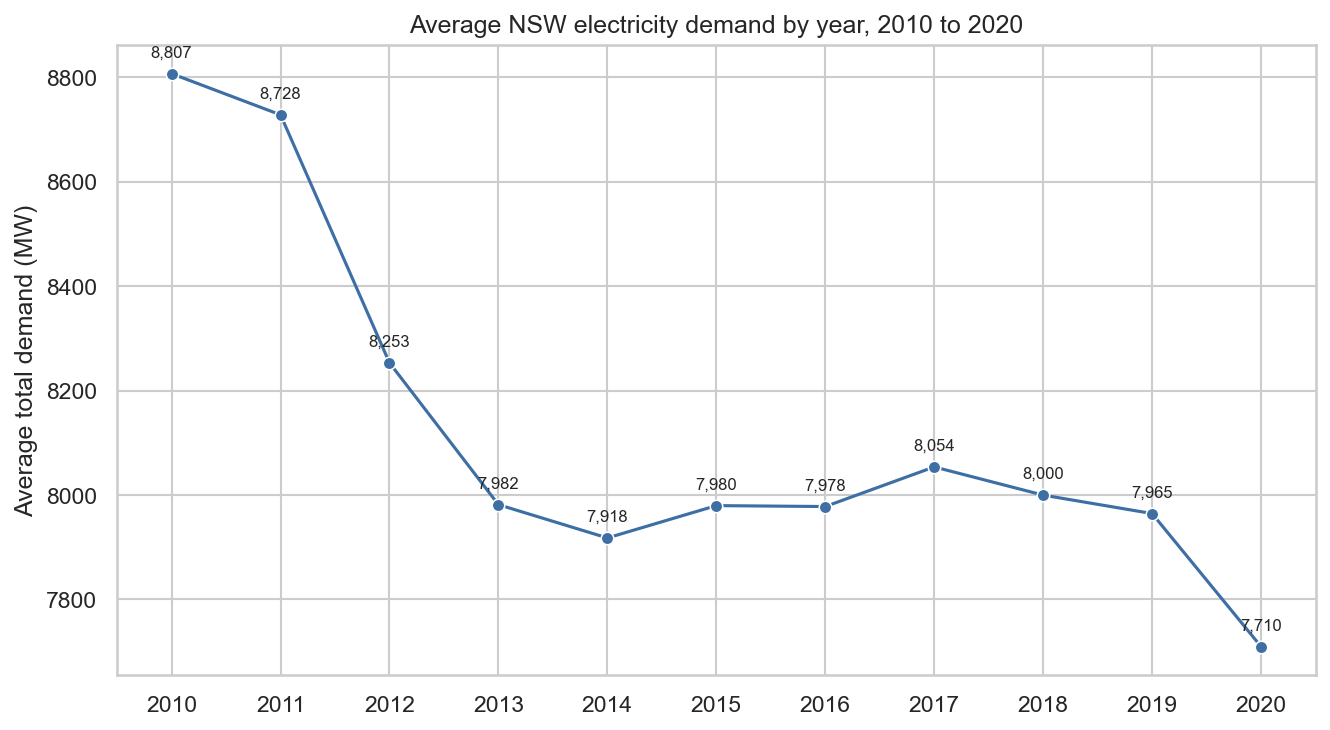

In [15]:
# yearly
yearly = complete_years.groupby("YEAR")["TOTALDEMAND"].mean()

log("yearly means:\n", yearly.round(2))

log(
    "2010 to 2020 pct change",
    round((yearly.loc[2020] / yearly.loc[2010] - 1) * 100, 2)
)

plt.figure(figsize=(9, 5))

ax = sns.lineplot(
    x=yearly.index,
    y=yearly.values,
    marker="o",
    color="#3d6fa5"
)

for x, v in yearly.items():
    ax.annotate(
        f"{v:,.0f}",
        (x, v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.title("Average NSW electricity demand by year, 2010 to 2020")
plt.xlabel("")
plt.ylabel("Average total demand (MW)")
plt.xticks(yearly.index)

plt.tight_layout()
plt.savefig(f"{FIG}/fig_yearly.png")
plt.show()

<p style="font-size:18px; font-style:italic;">
Figure 4.8. Average NSW electricity demand by calendar year.
</p>

## 4.4 How demand levels relate to year and season

In [16]:
# Demand level analysis

q1, q2 = df["TOTALDEMAND"].quantile([1/3, 2/3])

df["DEMAND_LEVEL"] = pd.cut(
    df["TOTALDEMAND"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Low", "Medium", "High"]
)

log("Demand band cut points:", round(q1, 2), round(q2, 2))

# Demand levels by year
year_band = pd.crosstab(
    df["YEAR"],
    df["DEMAND_LEVEL"],
    normalize="index"
) * 100

log("Demand level by year (%):\n", year_band.round(1))

# Demand levels by season
season_band = pd.crosstab(
    df["SEASON"],
    df["DEMAND_LEVEL"],
    normalize="index"
) * 100

season_band = season_band.reindex(season_order)

log("Demand level by season (%):\n", season_band.round(1))

Demand band cut points: 7475.48 8605.99
Demand level by year (%):
 DEMAND_LEVEL   Low  Medium  High
YEAR                            
2010          19.3    23.6  57.0
2011          19.7    25.3  55.0
2012          28.6    30.9  40.5
2013          34.5    35.7  29.7
2014          35.4    36.5  28.1
2015          35.3    35.4  29.3
2016          35.8    36.3  27.9
2017          33.8    37.2  28.9
2018          34.0    38.8  27.2
2019          38.0    35.7  26.3
2020          48.4    30.5  21.1
2021          51.7    36.2  12.1
Demand level by season (%):
 DEMAND_LEVEL   Low  Medium  High
SEASON                          
Summer        35.0    29.9  35.1
Autumn        36.5    36.1  27.4
Winter        18.7    27.3  53.9
Spring        43.1    40.2  16.7


## 4.5 Longer term structure, decomposition and autocorrelation

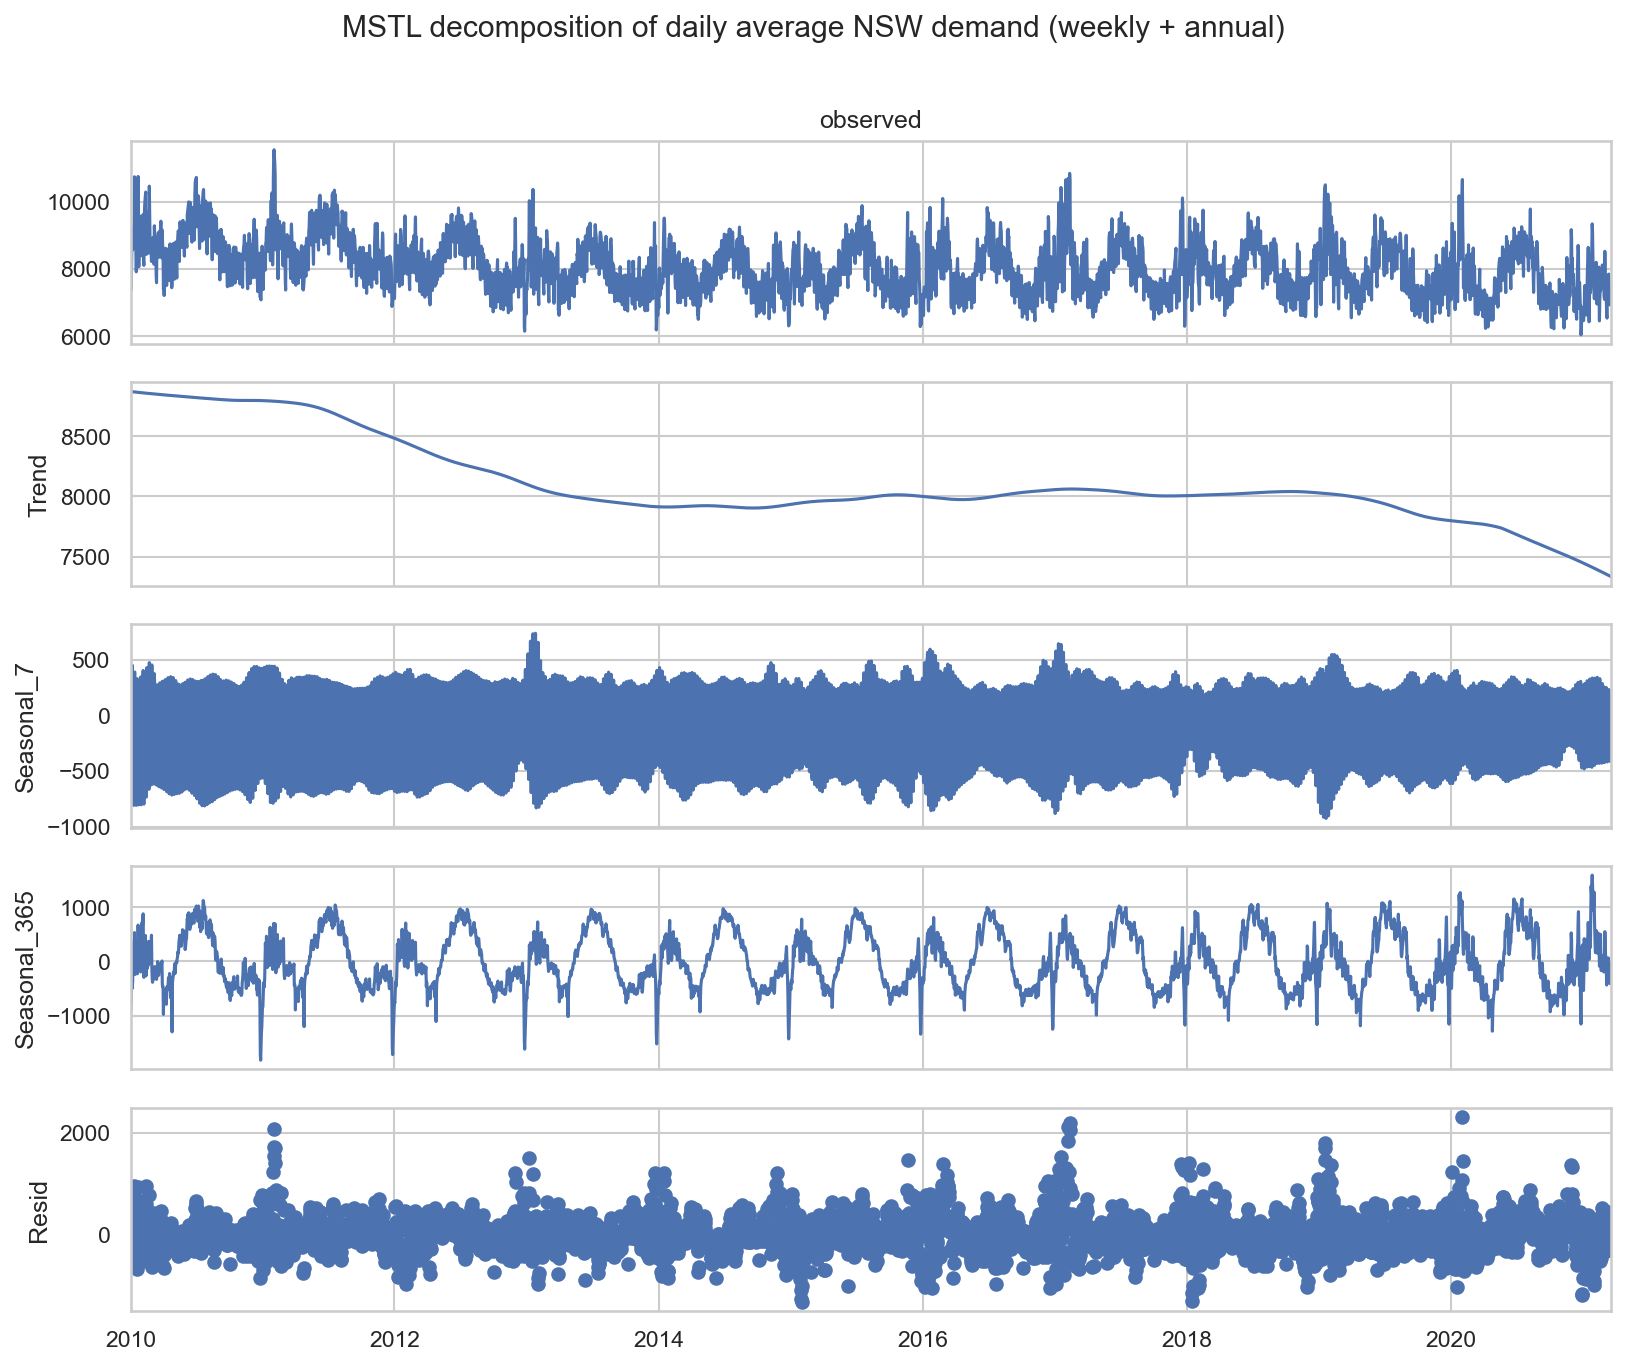

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import MSTL

sns.set_theme(style="whitegrid")
os.makedirs("figs", exist_ok=True)

# Use the df loaded from nsw_features_added.csv earlier in the notebook
assert len(df) == 196_513, "Check that the correct CSV was loaded"

daily = (
    df.assign(DATETIME=pd.to_datetime(df["DATETIME"]))
      .sort_values("DATETIME")
      .set_index("DATETIME")["TOTALDEMAND"]
      .resample("D")
      .mean()
)

mstl_fit = MSTL(
    daily,
    periods=(7, 365),
    stl_kwargs={"robust": False}
).fit()

fig = mstl_fit.plot()
fig.set_size_inches(11, 9)
fig.suptitle(
    "MSTL decomposition of daily average NSW demand (weekly + annual)",
    y=1.01
)

plt.tight_layout()
plt.savefig("figs/fig_mstl.png", dpi=150, bbox_inches="tight")
plt.show()

<p style="font-size:18px; font-style:italic;">
Figure 4.9. MSTL decomposition of daily average demand into trend, weekly seasonality, annual seasonality and residual.
</p>

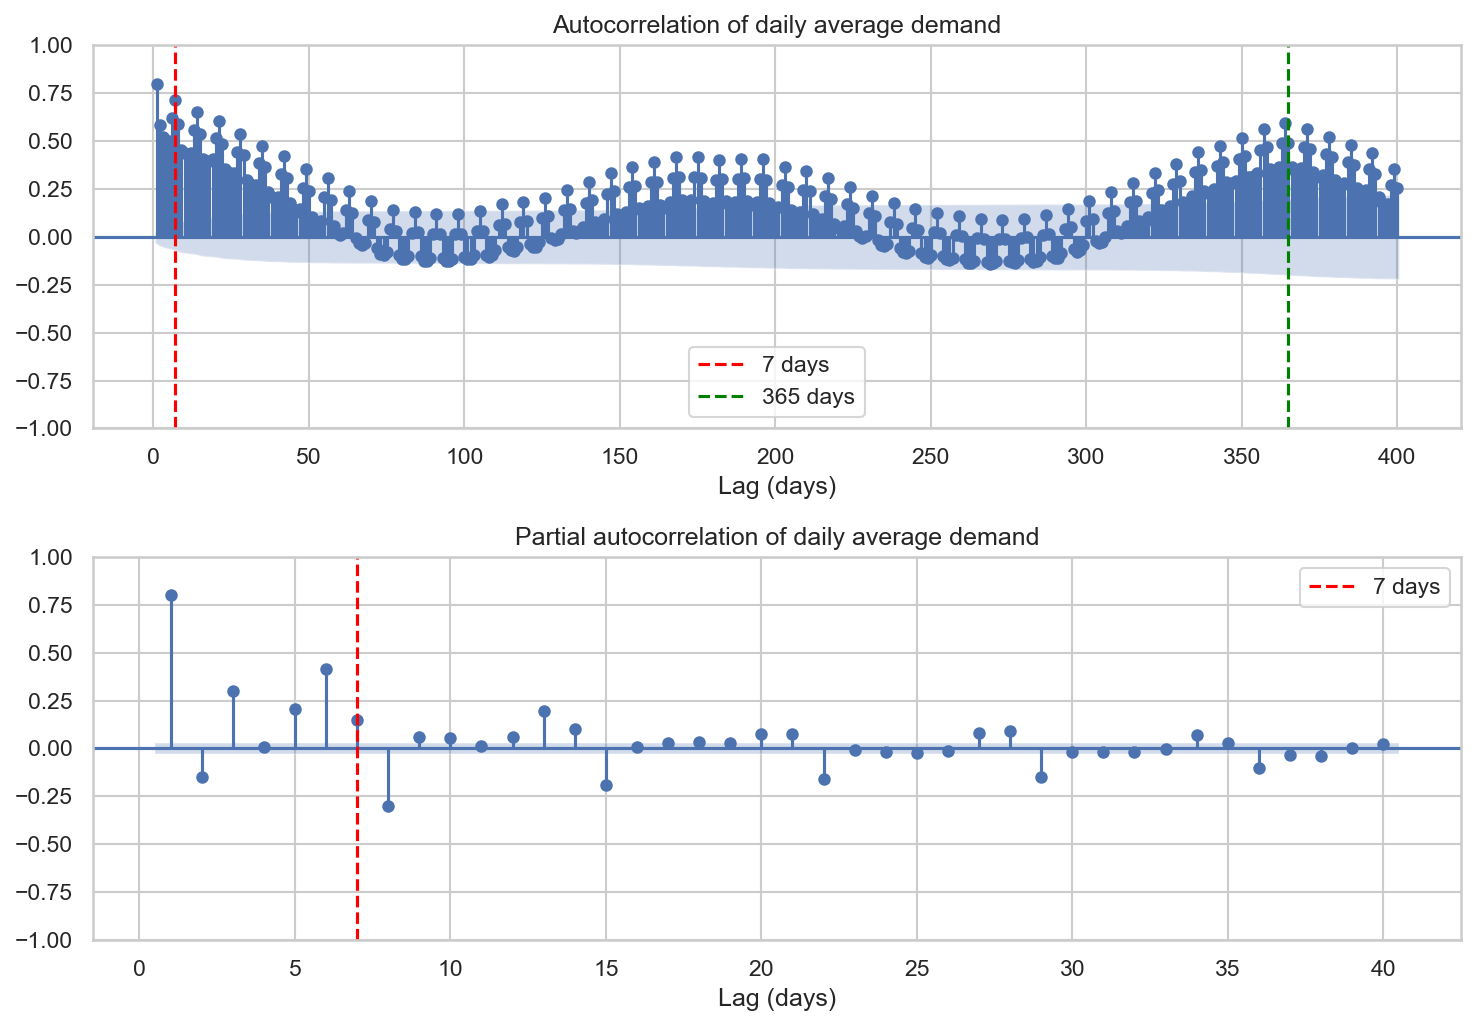

In [18]:
# ACF and PACF of daily average demand

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

plot_acf(
    daily.dropna(),
    lags=400,
    ax=axes[0],
    zero=False
)

axes[0].axvline(7, color="red", linestyle="--", label="7 days")
axes[0].axvline(365, color="green", linestyle="--", label="365 days")
axes[0].set_title("Autocorrelation of daily average demand")
axes[0].set_xlabel("Lag (days)")
axes[0].legend()

plot_pacf(
    daily.dropna(),
    lags=40,
    ax=axes[1],
    zero=False,
    method="ywm"
)

axes[1].axvline(7, color="red", linestyle="--", label="7 days")
axes[1].set_title("Partial autocorrelation of daily average demand")
axes[1].set_xlabel("Lag (days)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG}/fig_acf_pacf.png")
plt.show()

*Figure 4.10. Autocorrelation and partial autocorrelation of daily average demand.*

In [19]:
# Stationarity tests: ADF and KPSS

adf_result = adfuller(daily.dropna())

print("ADF statistic:", round(adf_result[0], 3))
print("ADF p-value:", adf_result[1])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpss_result = kpss(daily.dropna(), regression="c", nlags="auto")

print("KPSS statistic:", round(kpss_result[0], 3))
print("KPSS p-value:", kpss_result[1])

ADF statistic: -5.721
ADF p-value: 6.938188198185607e-07
KPSS statistic: 2.599
KPSS p-value: 0.01


## 4.6 Temperature and electricity demand

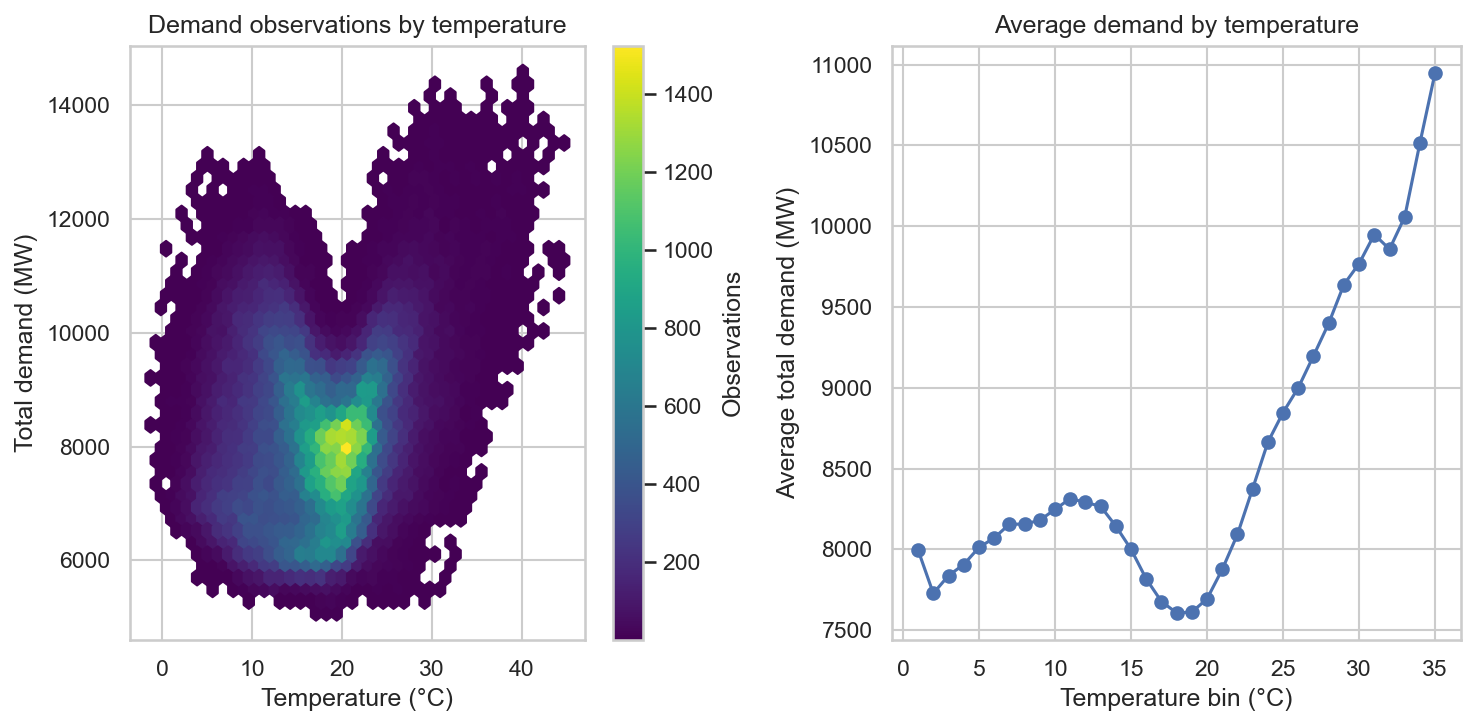

In [20]:
# Figure 4.11: Temperature and electricity demand
df["TEMP_BIN"] = np.floor(df["TEMPERATURE"]).astype(int)

temp_summary = (
    df.groupby("TEMP_BIN", observed=True)["TOTALDEMAND"]
      .agg(["mean", "count"])
      .reset_index()
)
temp_summary = temp_summary[temp_summary["count"] >= 100]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left: observation density
hb = axes[0].hexbin(
    df["TEMPERATURE"],
    df["TOTALDEMAND"],
    gridsize=40,
    cmap="viridis",
    mincnt=1
)
axes[0].set_title("Demand observations by temperature")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Total demand (MW)")
fig.colorbar(hb, ax=axes[0], label="Observations")

# Right: mean demand in one-degree temperature bins
axes[1].plot(
    temp_summary["TEMP_BIN"],
    temp_summary["mean"],
    marker="o"
)
axes[1].set_title("Average demand by temperature")
axes[1].set_xlabel("Temperature bin (°C)")
axes[1].set_ylabel("Average total demand (MW)")

plt.tight_layout()
plt.savefig(f"{FIG}/fig_temperature_demand.png")
plt.show()

*Figure 4.11. Relationship between temperature and NSW electricity demand, observation density on the left and average demand by one degree temperature bin on the right.*

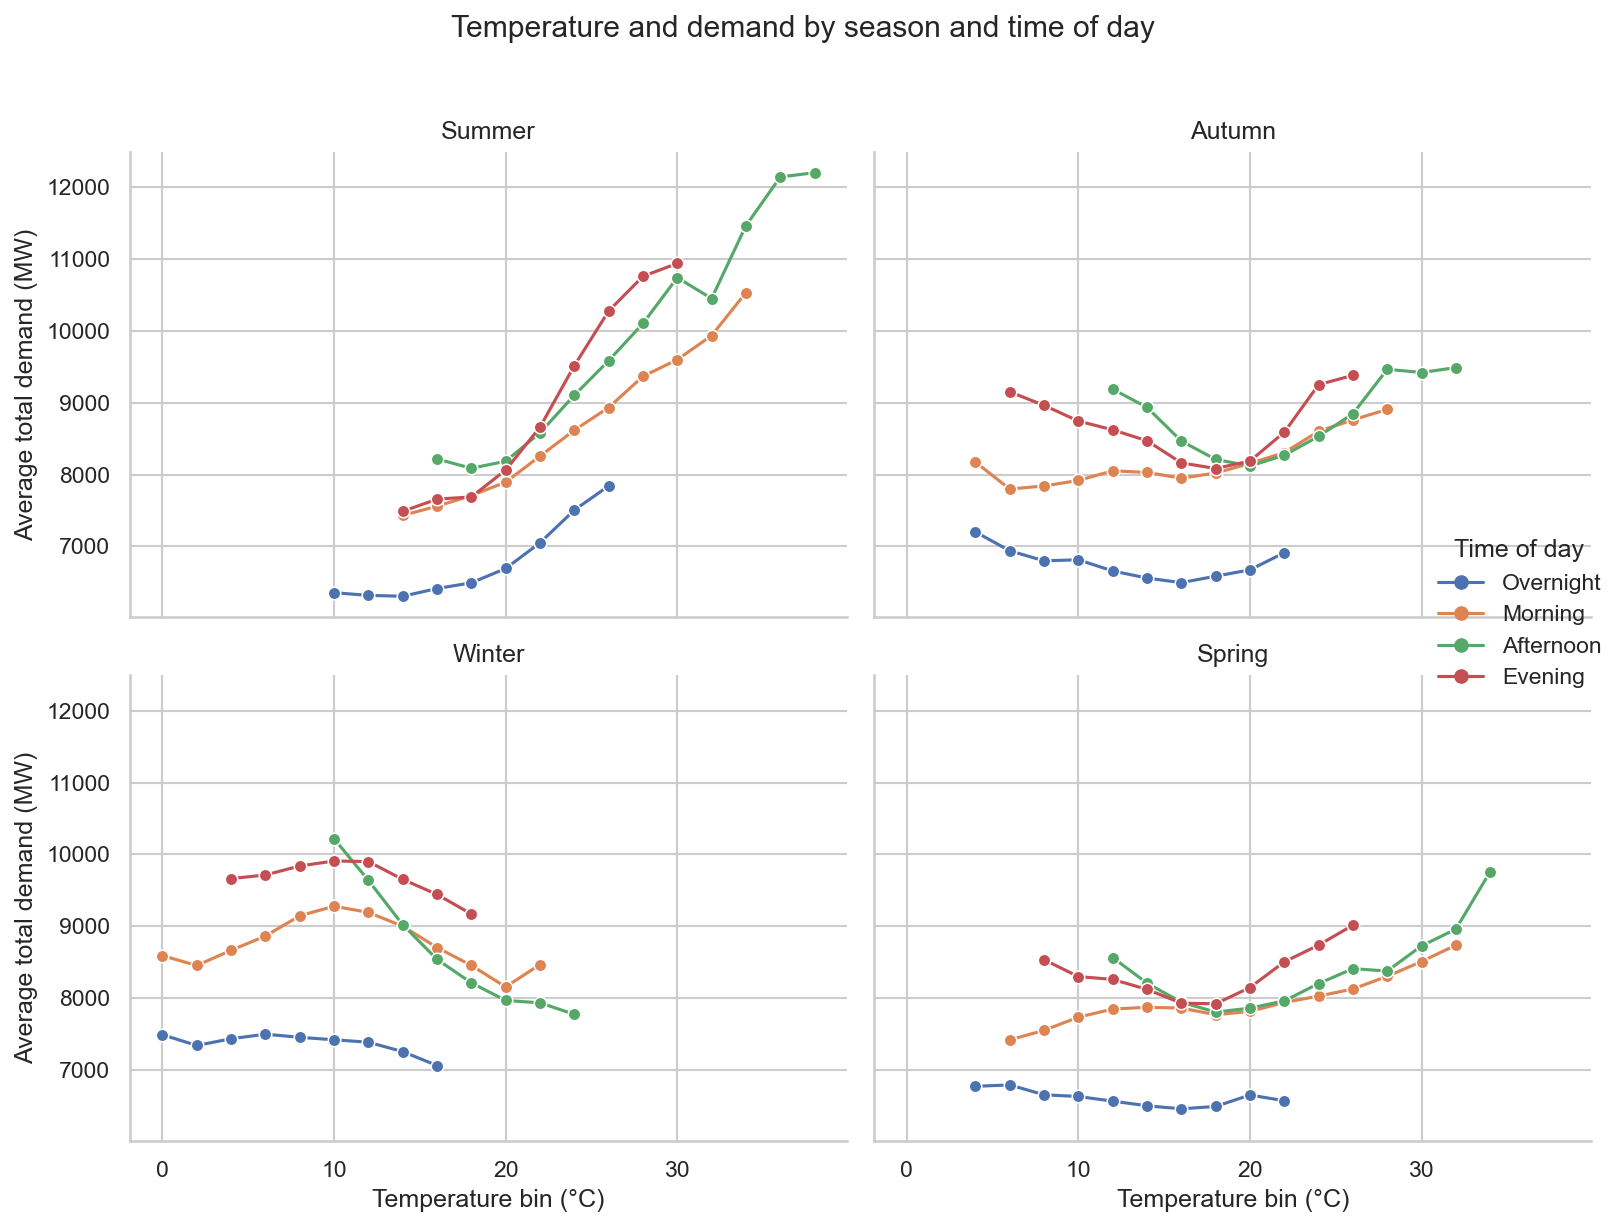

In [21]:
# Figure 4.12: Temperature and demand by season and time of day

def time_of_day(hour):
    if hour < 6:
        return "Overnight"
    if hour < 12:
        return "Morning"
    if hour < 18:
        return "Afternoon"
    return "Evening"

df["TIME_OF_DAY"] = df["DATETIME"].dt.hour.apply(time_of_day)

# Two-degree bins: ..., 18, 20, 22, ...
df["TEMP_BIN_2"] = (
    np.floor(df["TEMPERATURE"] / 2) * 2
).astype(int)

temp_season = (
    df.groupby(
        ["SEASON", "TIME_OF_DAY", "TEMP_BIN_2"],
        observed=True
    )["TOTALDEMAND"]
    .agg(["mean", "count"])
    .reset_index()
)

temp_season = temp_season[temp_season["count"] >= 50]

grid = sns.relplot(
    data=temp_season,
    x="TEMP_BIN_2",
    y="mean",
    hue="TIME_OF_DAY",
    col="SEASON",
    col_wrap=2,
    kind="line",
    marker="o",
    facet_kws={"sharex": True, "sharey": True},
    col_order=["Summer", "Autumn", "Winter", "Spring"],
    hue_order=["Overnight", "Morning", "Afternoon", "Evening"],
    height=4,
    aspect=1.2,
    legend="full"
)

grid.set_titles("{col_name}")
grid.set_axis_labels(
    "Temperature bin (°C)",
    "Average total demand (MW)"
)
grid._legend.set_title("Time of day")
grid.figure.suptitle(
    "Temperature and demand by season and time of day",
    y=1.02
)

plt.tight_layout()
for ax in grid.axes.flat:
    ax.set_xticks([0, 10, 20, 30])
grid.savefig(
    f"{FIG}/fig_temperature_season_time.png",
    bbox_inches="tight"
)
plt.show()

*Figure 4.12. Average demand across temperature bins, separated by season and time of day.*

## 4.7 Public holidays and school terms

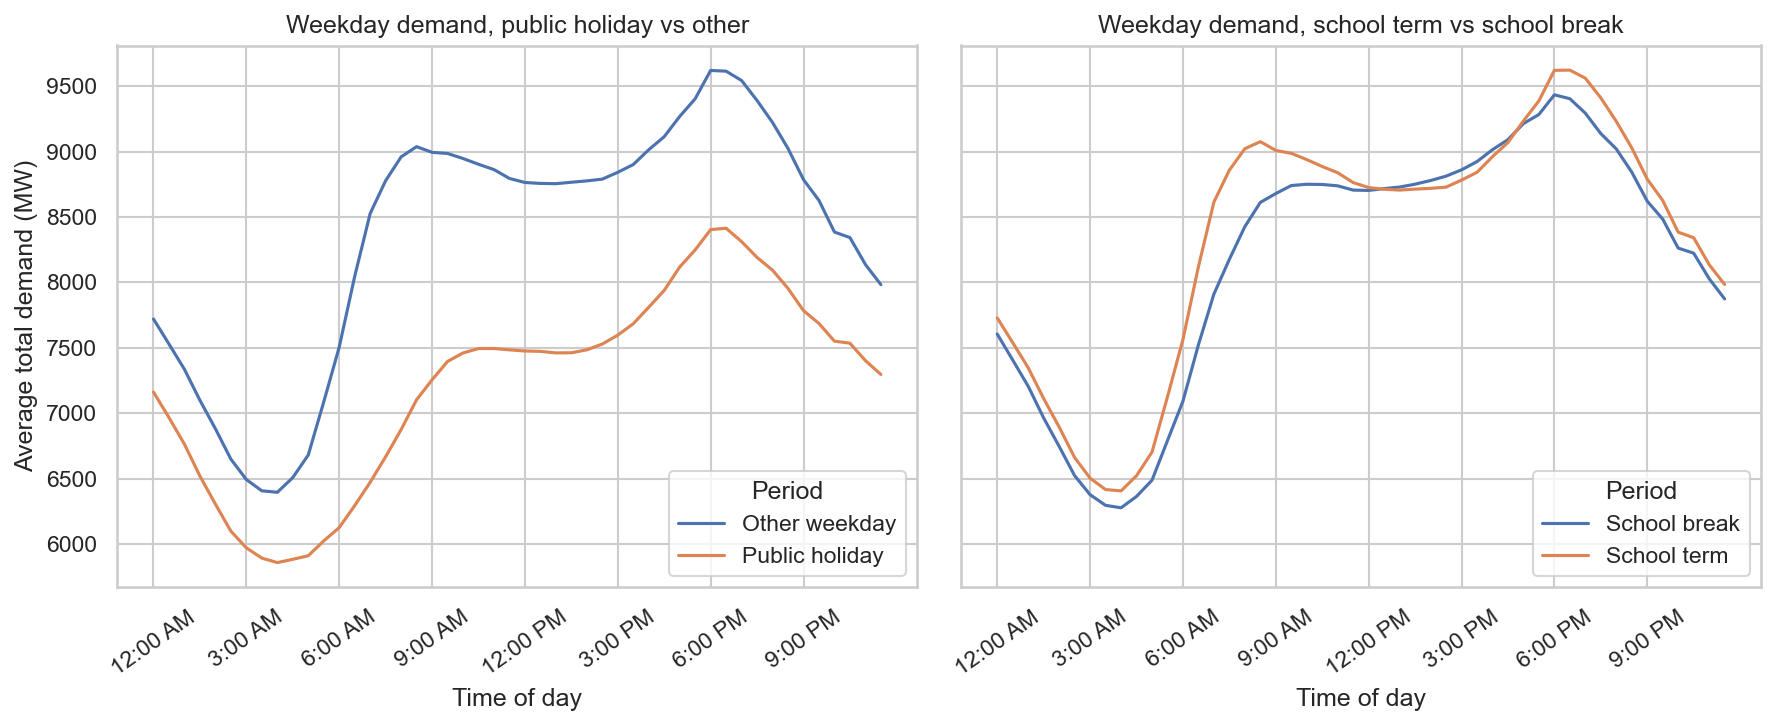

In [22]:
# Figure 4.13: Weekday demand on public holidays and school terms

weekday_df = df[df["IS_WEEKEND"] == False].copy()

weekday_df["HOUR"] = (
    weekday_df["DATETIME"].dt.hour
    + weekday_df["DATETIME"].dt.minute / 60
)

weekday_df["HOLIDAY_PERIOD"] = np.where(
    weekday_df["is_public_holiday"],
    "Public holiday",
    "Other weekday"
)

weekday_df["SCHOOL_PERIOD"] = np.where(
    weekday_df["is_school_term"],
    "School term",
    "School break"
)

holiday_profile = (
    weekday_df
    .groupby(["HOUR", "HOLIDAY_PERIOD"], observed=True)["TOTALDEMAND"]
    .mean()
    .reset_index()
)

school_profile = (
    weekday_df
    .groupby(["HOUR", "SCHOOL_PERIOD"], observed=True)["TOTALDEMAND"]
    .mean()
    .reset_index()
)

# Share the y-axis: show its numbers only on the left panel
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.lineplot(
    data=holiday_profile,
    x="HOUR",
    y="TOTALDEMAND",
    hue="HOLIDAY_PERIOD",
    hue_order=["Other weekday", "Public holiday"],
    ax=axes[0]
)
axes[0].set_title("Weekday demand, public holiday vs other")
axes[0].set_xlabel("Time of day")
axes[0].set_ylabel("Average total demand (MW)")
axes[0].legend(title="Period", loc="lower right")

sns.lineplot(
    data=school_profile,
    x="HOUR",
    y="TOTALDEMAND",
    hue="SCHOOL_PERIOD",
    hue_order=["School break", "School term"],
    ax=axes[1]
)
axes[1].set_title("Weekday demand, school term vs school break")
axes[1].set_xlabel("Time of day")
axes[1].set_ylabel("")
axes[1].legend(title="Period", loc="lower right")

for ax in axes:
    ax.set_xticks([0, 3, 6, 9, 12, 15, 18, 21])
    ax.set_xticklabels(
        [
            "12:00 AM", "3:00 AM", "6:00 AM", "9:00 AM",
            "12:00 PM", "3:00 PM", "6:00 PM", "9:00 PM"
        ],
        rotation=35
    )

plt.tight_layout()
plt.savefig(f"{FIG}/fig_holiday_schoolterm.png")
plt.show()

*Figure 4.13. Weekday demand on public holidays versus other weekdays on the left, and during school term versus school breaks on the right.*

## 4.8 Existing forecast performance

In [23]:

# Table 4.1: Overall accuracy of existing operator forecasts

forecast_cols = {
    "Closest forecast": "forecast_closest",
    "12-hour prior": "forecast_12hr_prior",
    "Day prior": "forecast_dayprior"
}

rows = []

for name, col in forecast_cols.items():

    actual = df["TOTALDEMAND"]
    forecast = df[col]

    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = mean_absolute_percentage_error(actual, forecast) * 100

    # Bias defined as actual minus forecast to match the report
    bias = (actual - forecast).mean()

    rows.append({
        "Forecast": name,
        "MAE (MW)": mae,
        "RMSE (MW)": rmse,
        "MAPE (%)": mape,
        "Bias (MW)": bias
    })

forecast_accuracy = pd.DataFrame(rows)

print(
    forecast_accuracy.round(2).to_string(index=False)
)

        Forecast  MAE (MW)  RMSE (MW)  MAPE (%)  Bias (MW)
Closest forecast     62.33      85.87      0.76      -9.11
   12-hour prior    169.08     234.87      2.05       8.20
       Day prior    177.83     247.03      2.16       9.60


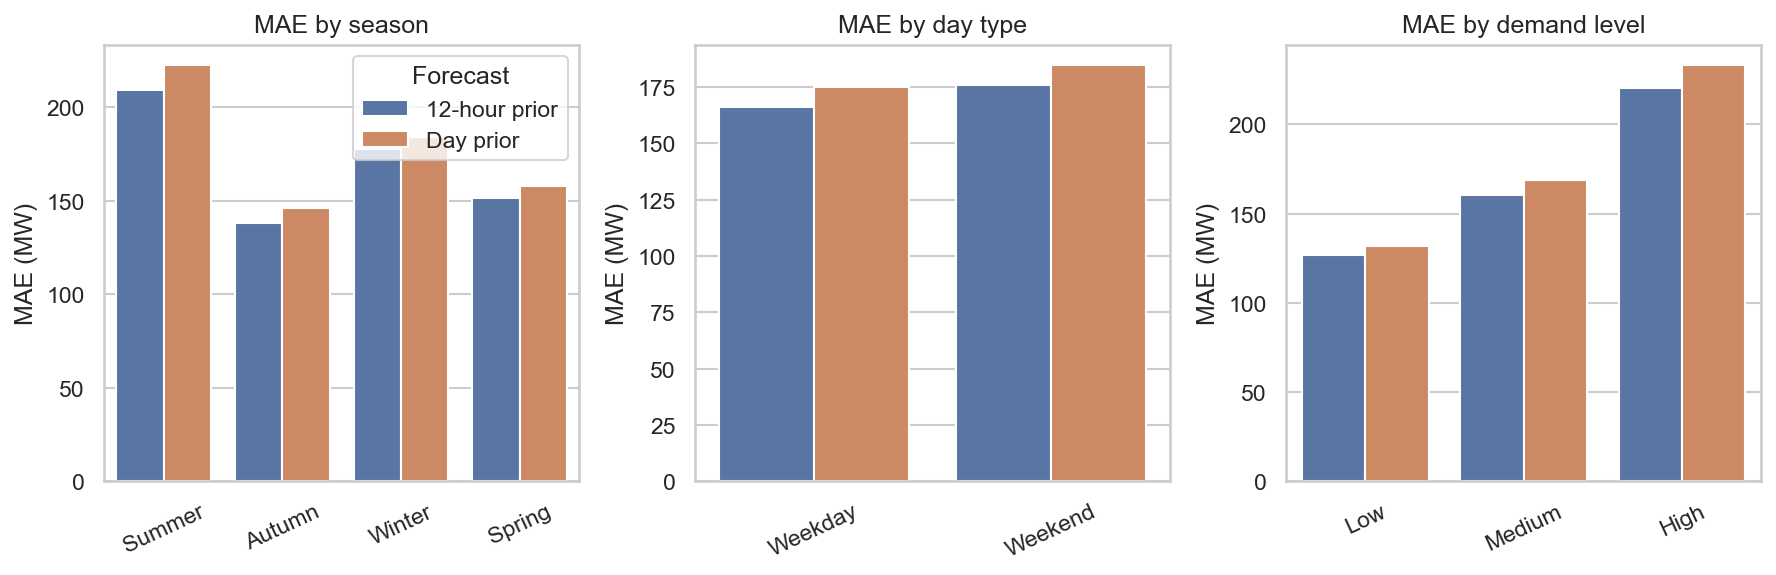

In [24]:
# Figure 4.14: Forecast MAE by season, day type and demand level

# Forecast columns
forecast_cols = {
    "12-hour prior": "forecast_12hr_prior",
    "Day prior": "forecast_dayprior"
}

# Function to calculate MAE by group
def mae_by_group(data, group_col):
    rows = []

    for group_name, group_data in data.groupby(group_col, observed=True):
        actual = group_data["TOTALDEMAND"]

        for forecast_name, forecast_col in forecast_cols.items():
            forecast = group_data[forecast_col]

            valid = actual.notna() & forecast.notna()

            mae = mean_absolute_error(
                actual[valid],
                forecast[valid]
            )

            rows.append({
                "Group": group_name,
                "Forecast": forecast_name,
                "MAE": mae
            })

    return pd.DataFrame(rows)


# Calculate MAE for each condition
season_mae = mae_by_group(df, "SEASON")
daytype_mae = mae_by_group(df, "DAY_TYPE")
demand_mae = mae_by_group(df, "DEMAND_LEVEL")


# Set the order to match the report
season_order = ["Summer", "Autumn", "Winter", "Spring"]
daytype_order = ["Weekday", "Weekend"]
demand_order = ["Low", "Medium", "High"]


# Create the three plots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))


# MAE by season
sns.barplot(
    data=season_mae,
    x="Group",
    y="MAE",
    hue="Forecast",
    order=season_order,
    ax=axes[0]
)

axes[0].set_title("MAE by season")
axes[0].set_xlabel("")
axes[0].set_ylabel("MAE (MW)")
axes[0].tick_params(axis="x", rotation=25)


# MAE by day type
sns.barplot(
    data=daytype_mae,
    x="Group",
    y="MAE",
    hue="Forecast",
    order=daytype_order,
    ax=axes[1]
)

axes[1].set_title("MAE by day type")
axes[1].set_xlabel("")
axes[1].set_ylabel("MAE (MW)")
axes[1].tick_params(axis="x", rotation=25)

# Remove duplicate legend
axes[1].get_legend().remove()


# MAE by demand level
sns.barplot(
    data=demand_mae,
    x="Group",
    y="MAE",
    hue="Forecast",
    order=demand_order,
    ax=axes[2]
)

axes[2].set_title("MAE by demand level")
axes[2].set_xlabel("")
axes[2].set_ylabel("MAE (MW)")
axes[2].tick_params(axis="x", rotation=25)

# Remove duplicate legend
axes[2].get_legend().remove()


plt.tight_layout()

plt.savefig(
    f"{FIG}/fig_forecast_mae_conditions.png",
    bbox_inches="tight"
)

plt.show()

*Figure 4.14. Mean absolute error of the 12-hour prior and day prior forecasts, split by season, day type and demand level.*

In [25]:
# Table 4.2: Forecast accuracy by observed temperature band

# Create temperature bands
df["TEMP_CONDITION"] = pd.cut(
    df["TEMPERATURE"],
    bins=[-np.inf, 10, 20, 30, np.inf],
    labels=["Cold", "Mild", "Warm", "Hot"],
    right=False
)

# Labels used in the report
temp_labels = {
    "Cold": "Cold (under 10°C)",
    "Mild": "Mild (10 to 20°C)",
    "Warm": "Warm (20 to 30°C)",
    "Hot": "Hot (30°C or above)"
}

rows = []

for condition in ["Cold", "Mild", "Warm", "Hot"]:

    group = df[df["TEMP_CONDITION"] == condition]

    actual = group["TOTALDEMAND"]

    # 12-hour prior MAE
    valid_12 = actual.notna() & group["forecast_12hr_prior"].notna()

    mae_12 = mean_absolute_error(
        actual[valid_12],
        group.loc[valid_12, "forecast_12hr_prior"]
    )

    # Day prior MAE
    valid_day = actual.notna() & group["forecast_dayprior"].notna()

    mae_day = mean_absolute_error(
        actual[valid_day],
        group.loc[valid_day, "forecast_dayprior"]
    )

    rows.append({
        "Temperature band": temp_labels[condition],
        "Observations": len(group),
        "12-hour prior MAE (MW)": mae_12,
        "Day prior MAE (MW)": mae_day
    })


temperature_accuracy = pd.DataFrame(rows)

# Display Table 4.2
display(
    temperature_accuracy.style
    .hide(axis="index")
    .format({
        "Observations": "{:,.0f}",
        "12-hour prior MAE (MW)": "{:.2f}",
        "Day prior MAE (MW)": "{:.2f}"
    })
)


Temperature band,Observations,12-hour prior MAE (MW),Day prior MAE (MW)
Cold (under 10°C),"21,948",136.65,141.44
Mild (10 to 20°C),"104,343",154.36,161.43
Warm (20 to 30°C),"66,948",193.13,204.80
Hot (30°C or above),"3,274",363.76,392.88


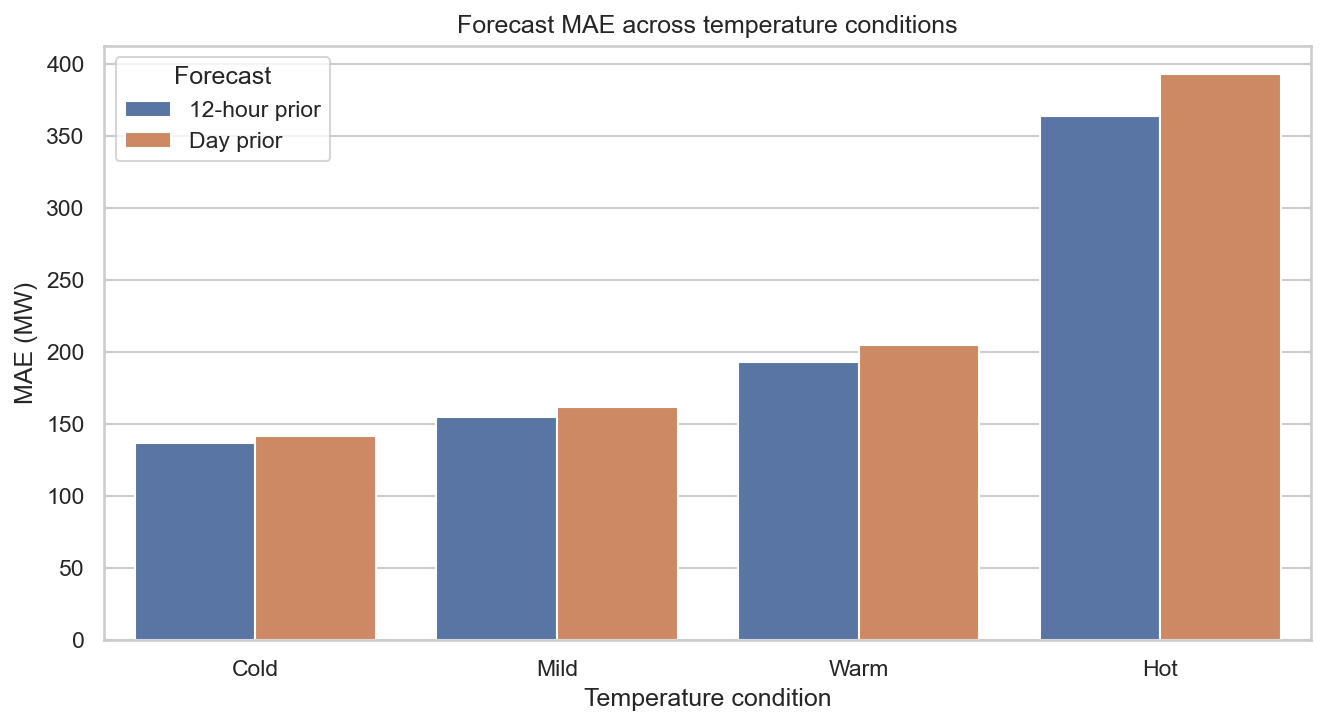

In [26]:
# Figure 4.15: Forecast MAE across temperature conditions

plot_temp = temperature_accuracy.copy()

plot_temp["Temperature condition"] = [
    "Cold", "Mild", "Warm", "Hot"
]

plot_temp = plot_temp.melt(
    id_vars="Temperature condition",
    value_vars=[
        "12-hour prior MAE (MW)",
        "Day prior MAE (MW)"
    ],
    var_name="Forecast",
    value_name="MAE"
)

plot_temp["Forecast"] = plot_temp["Forecast"].replace({
    "12-hour prior MAE (MW)": "12-hour prior",
    "Day prior MAE (MW)": "Day prior"
})

plt.figure(figsize=(9, 5))

sns.barplot(
    data=plot_temp,
    x="Temperature condition",
    y="MAE",
    hue="Forecast",
    order=["Cold", "Mild", "Warm", "Hot"]
)

plt.title("Forecast MAE across temperature conditions")
plt.xlabel("Temperature condition")
plt.ylabel("MAE (MW)")
plt.legend(title="Forecast")

plt.tight_layout()
plt.savefig(f"{FIG}/fig_forecast_mae_temperature.png")
plt.show()

*Figure 4.15. Forecast MAE across temperature conditions.*

## EDA Summary

The exploratory analysis identified clear daily, weekly and seasonal patterns in NSW electricity demand. Demand also varied across temperature conditions and changed over the study period. The analysis showed strong temporal dependence and highlighted differences in forecast error across demand and temperature conditions. These findings provide the basis for the modelling and evaluation stages of the project.